# Notebook 06b — Structural Cluster Evaluation (Adult-Only Rerun)

This notebook evaluates the K-Prototypes clustering solutions produced in
notebook 05b on the adult-only ACS PUMS dataset.

Its objectives are to compare k = 6, 7, and 8; assess cluster balance and
interpretability; estimate weighted cluster sizes using PWGTP; and profile
each cluster across key structural and demographic features.

The final output is the selection of the best k and the export of a revised
structural archetype registry to replace the one produced in notebook 06.

Key differences from notebook 06:
- Adult-only population (minors excluded via actor_class filter)
- K-Prototypes only — K-Modes and MCA+K-Means not re-evaluated
- 12 clustering features (commute_tier and puma removed)
- Models loaded from _v2 files saved by notebook 05b

In [1]:
# Environment setup
# Core libraries
from pathlib import Path
import warnings

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model loading
import joblib

# Clustering metrics
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

warnings.filterwarnings("ignore")

# Display options
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

# Plot style
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid")

In [2]:
# ── Paths  
# This notebook lives at Market_Kinetics/notebooks/
# parents[0] = notebooks/
# parents[1] = Market_Kinetics/  ← project root

PROJECT_ROOT  = Path().resolve().parent
DATA_DIR      = PROJECT_ROOT / "data"
INTERIM_DIR   = DATA_DIR / "societal_interim"
PROCESSED_DIR = DATA_DIR / "societal_processed"
MODELS_DIR    = DATA_DIR / "societal_models"

# ── Input files (v2 — produced by notebook 05b) ───────────────────────────────
STRUCTURAL_PATH     = INTERIM_DIR / "acs_pums_5y" / "mk_structural_population_layer_v1.parquet"
EXPERIMENT_RESULTS  = MODELS_DIR / "clustering_experiment_results_v2.csv"
X_KPROTOTYPES_PATH  = MODELS_DIR / "X_kprototypes_v2.joblib"
CAT_COL_IDX_PATH    = MODELS_DIR / "cat_col_indices_v2.joblib"
DF_CLUSTER_PATH     = MODELS_DIR / "df_cluster_v2.joblib"

# ── Candidate model files (v2 only) ───────────────────────────────────────────
kprototypes_models = sorted(MODELS_DIR.glob("kprototypes_v2_k*.joblib"))

# ── Verification ──────────────────────────────────────────────────────────────
print("=" * 60)
print("PATH VERIFICATION")
print("=" * 60)
print(f"Project root      : {PROJECT_ROOT}")
print(f"Structural data   : {STRUCTURAL_PATH.exists()} — {STRUCTURAL_PATH.name}")
print(f"Experiment results: {EXPERIMENT_RESULTS.exists()} — {EXPERIMENT_RESULTS.name}")
print(f"X_kprototypes     : {X_KPROTOTYPES_PATH.exists()}")
print(f"cat_col_indices   : {CAT_COL_IDX_PATH.exists()}")
print(f"df_cluster        : {DF_CLUSTER_PATH.exists()}")
print(f"\nK-Prototypes v2 models found: {len(kprototypes_models)}")
for p in kprototypes_models:
    print(f"  {p.name}")

PATH VERIFICATION
Project root      : /Users/marcomagnolo/Projects/Market_Kinetics
Structural data   : True — mk_structural_population_layer_v1.parquet
Experiment results: True — clustering_experiment_results_v2.csv
X_kprototypes     : True
cat_col_indices   : True
df_cluster        : True

K-Prototypes v2 models found: 3
  kprototypes_v2_k6.joblib
  kprototypes_v2_k7.joblib
  kprototypes_v2_k8.joblib


In [3]:
# ── Load data ─────────────────────────────────────────────────────────────────
df_population = pd.read_parquet(STRUCTURAL_PATH)
df_results    = pd.read_csv(EXPERIMENT_RESULTS)

# Filter to adults — must match the population used in 05b
df_population = df_population[df_population['actor_class'] == 'Adult'].copy()

print(f"Adult population  : {len(df_population):,} records")
print(f"Experiment results: {df_results.shape}")
print(f"\nResults preview:")
print(df_results[["algorithm", "k", "cost"]])

Adult population  : 778,466 records
Experiment results: (3, 4)

Results preview:
      algorithm  k          cost
0  K-Prototypes  6  3.374194e+06
1  K-Prototypes  7  3.248431e+06
2  K-Prototypes  8  3.159243e+06


In [4]:
display(df_population.head())
display(df_results.head())

,serialno,sporder,pwgtp,actor_class,age_bin,sex_label,race_eth,edu_tier,emp_tier,income_tier_fixed,income_tier_pct,mar_tier,commute_tier,tenure,household_size,vehicle_count,puma,hhincome_tier,household_type
0,2023HU1043211,2,58,Adult,35-44,Male,Black_NH,HS_or_less,Employed,0-19k,P0-20,Never_Married,Car,3,2,0,4316,0-19k,housing_unit
1,2019HU1076190,2,46,Adult,35-44,Male,Black_NH,HS_or_less,Employed,0-19k,P20-40,Never_Married,Car,3,4,2,5922,20-49k,housing_unit
2,2019GQ0046130,1,12,Adult,35-44,Male,Black_NH,HS_or_less,Other_Not_in_Labor_Force,0-19k,P0-20,Never_Married,NaN,group_quarters,1,0,11300,group_quarters,group_quarters
3,2019HU0403832,1,76,Adult,35-44,Male,Black_NH,HS_or_less,Employed,0-19k,P0-20,Never_Married,Work_From_Home,1,5,2,2510,50-99k,housing_unit
4,2019HU0277198,1,64,Adult,35-44,Male,Black_NH,HS_or_less,Employed,0-19k,P0-20,Never_Married,Car,3,4,1,4607,20-49k,housing_unit


,algorithm,k,cost,cluster_sizes
0,K-Prototypes,6,3.374194e+06,"{0: 176508, 1: 105440, 2: 163695, 3: 38506, 4:..."
1,K-Prototypes,7,3.248431e+06,"{0: 40245, 1: 114528, 2: 153691, 3: 134600, 4:..."
2,K-Prototypes,8,3.159243e+06,"{0: 119981, 1: 147366, 2: 66987, 3: 135378, 4:..."


In [5]:
df_population.info()

<class 'pandas.DataFrame'>
Index: 778466 entries, 0 to 999999
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   serialno           778466 non-null  str     
 1   sporder            778466 non-null  int64   
 2   pwgtp              778466 non-null  int64   
 3   actor_class        778466 non-null  str     
 4   age_bin            778466 non-null  string  
 5   sex_label          778466 non-null  string  
 6   race_eth           778466 non-null  string  
 7   edu_tier           778466 non-null  string  
 8   emp_tier           778466 non-null  str     
 9   income_tier_fixed  778466 non-null  string  
 10  income_tier_pct    778466 non-null  str     
 11  mar_tier           778466 non-null  string  
 12  commute_tier       467929 non-null  category
 13  tenure             778466 non-null  string  
 14  household_size     778466 non-null  int64   
 15  vehicle_count      778466 non-null  Int64   
 16  

In [6]:
df_results.columns.tolist()

['algorithm', 'k', 'cost', 'cluster_sizes']

In [7]:
# sort by algorithm and n_clusters
df_results.sort_values(["algorithm", "k"]).head(20)

,algorithm,k,cost,cluster_sizes
0,K-Prototypes,6,3.374194e+06,"{0: 176508, 1: 105440, 2: 163695, 3: 38506, 4:..."
1,K-Prototypes,7,3.248431e+06,"{0: 40245, 1: 114528, 2: 153691, 3: 134600, 4:..."
2,K-Prototypes,8,3.159243e+06,"{0: 119981, 1: 147366, 2: 66987, 3: 135378, 4:..."


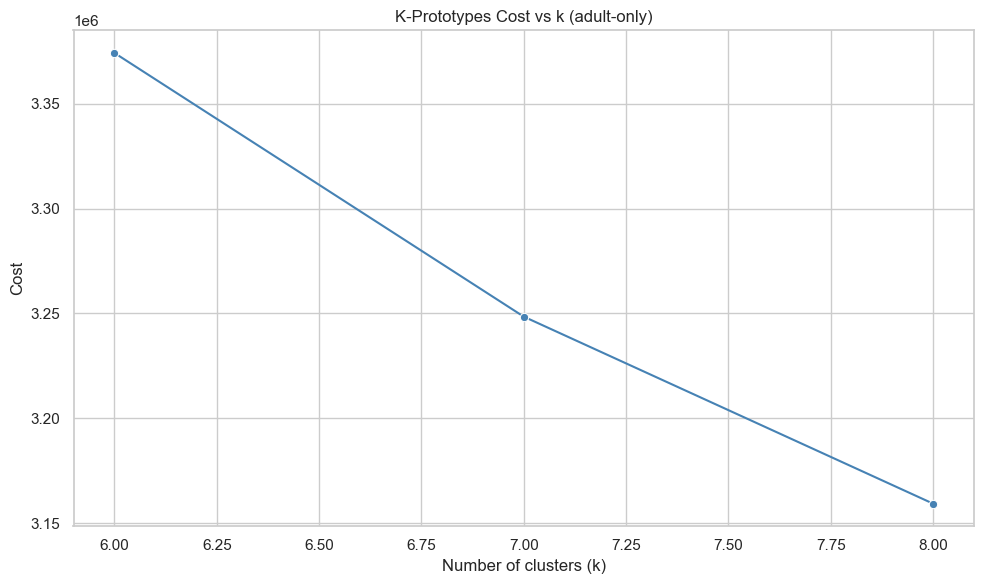

In [8]:
sns.lineplot(
    data=df_results,
    x="k",
    y="cost",
    marker="o",
    color="steelblue"
)

plt.title("K-Prototypes Cost vs k (adult-only)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Cost")
plt.tight_layout()
plt.show()

### Cost Analysis

The cost curve shows a consistent linear decline across k = 6, 7, and 8
with no clear elbow — meaning cost continues to decrease at a roughly
constant rate as k increases. This is common when only evaluating a narrow
k range (3 values vs the original k=4–15 sweep).

Key observations:
- k=6 → 3.374M
- k=7 → 3.248M  (-126k, -3.7%)
- k=8 → 3.159M  (-89k,  -2.7%)

The rate of improvement is already slowing (126k drop vs 89k drop),
which is consistent with k=7 sitting near the elbow of the full curve.
Cost alone cannot determine the winner here — cluster balance and
interpretability will be the deciding factors, evaluated in the
profiling steps below.

In [9]:
# Inspecting cluster sizes
df_results[['algorithm', 'k', 'cluster_sizes']].head(12)

,algorithm,k,cluster_sizes
0,K-Prototypes,6,"{0: 176508, 1: 105440, 2: 163695, 3: 38506, 4:..."
1,K-Prototypes,7,"{0: 40245, 1: 114528, 2: 153691, 3: 134600, 4:..."
2,K-Prototypes,8,"{0: 119981, 1: 147366, 2: 66987, 3: 135378, 4:..."


In [10]:
# Parsing cluster Size Dictionraries
import ast

df_results["cluster_sizes_dict"] = df_results["cluster_sizes"].apply(ast.literal_eval)

df_results[["algorithm", "k", "cluster_sizes_dict"]].head()

,algorithm,k,cluster_sizes_dict
0,K-Prototypes,6,"{0: 176508, 1: 105440, 2: 163695, 3: 38506, 4:..."
1,K-Prototypes,7,"{0: 40245, 1: 114528, 2: 153691, 3: 134600, 4:..."
2,K-Prototypes,8,"{0: 119981, 1: 147366, 2: 66987, 3: 135378, 4:..."


In [11]:
def compute_balance_metrics(d):
    sizes = list(d.values())
    return pd.Series({
        "min_cluster":     min(sizes),
        "max_cluster":     max(sizes),
        "imbalance_ratio": round(max(sizes) / min(sizes), 2)
    })

balance_metrics = df_results["cluster_sizes_dict"].apply(compute_balance_metrics)
df_results      = pd.concat([df_results, balance_metrics], axis=1)

print("Balance metrics:")
print(df_results[["k", "min_cluster", "max_cluster", "imbalance_ratio"]].to_string(index=False))

Balance metrics:
 k  min_cluster  max_cluster  imbalance_ratio
 6      38506.0     190372.0             4.94
 7      40245.0     153691.0             3.82
 8      35635.0     147366.0             4.14


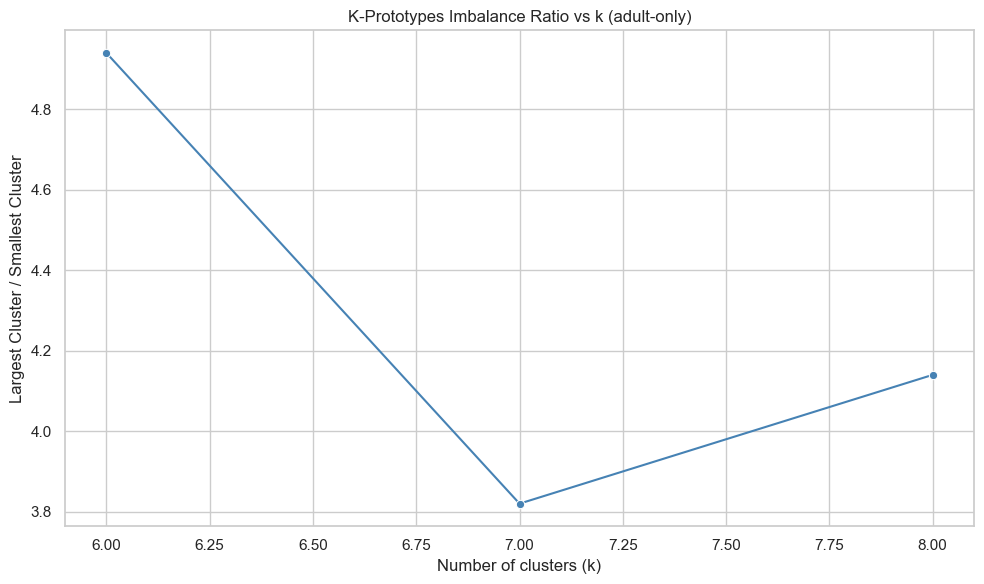

In [12]:
# visualzing imbalance ratio vs k
sns.lineplot(
    data=df_results,
    x="k",
    y="imbalance_ratio",
    marker="o",
    color="steelblue"
)

plt.title("K-Prototypes Imbalance Ratio vs k (adult-only)")
plt.ylabel("Largest Cluster / Smallest Cluster")
plt.xlabel("Number of clusters (k)")
plt.tight_layout()
plt.show()

### Balance Analysis

k=7 produces the most balanced segmentation with an imbalance ratio of 3.82
— meaningfully better than both k=6 (4.94) and k=8 (4.14).

Critically, all seven clusters in the k=7 solution represent at least 40,000
adults, ensuring every segment is a substantial and targetable population
group. The k=8 solution drops one cluster to 35,635 — still viable but
trending toward fragmentation.

Combined with the cost analysis, **k=7 is selected as the final solution.**
Cluster profiling below will confirm interpretability.

## Candidate Models for Profiling

Based on cost and balance analysis, all three K-Prototypes solutions
are carried forward for cluster profiling. k=7 is the leading candidate
but k=6 and k=8 are profiled for comparison before the final decision
is confirmed.

- **K-Prototypes k=6** — imbalance ratio 4.94, one dominant cluster
- **K-Prototypes k=7** — imbalance ratio 3.82, best balance
- **K-Prototypes k=8** — imbalance ratio 4.14, smallest cluster at 35k

Profiling will evaluate whether k=7 produces interpretable and
actionable segments across employment, income, tenure, and demographics.

In [13]:
# k=7 selected based on cost and balance analysis
candidate_models = [
    ("K-Prototypes", 6),
    ("K-Prototypes", 7),
    ("K-Prototypes", 8),
]

df_shortlist = pd.DataFrame(candidate_models, columns=["algorithm", "k"])
print(df_shortlist.to_string(index=False))

   algorithm  k
K-Prototypes  6
K-Prototypes  7
K-Prototypes  8


In [14]:
# Function to get model path based on algorithm and k
def get_model_path(algorithm, k):
    if algorithm == "K-Prototypes":
        return MODELS_DIR / f"kprototypes_v2_k{k}.joblib"
    else:
        raise ValueError(f"Unknown algorithm: {algorithm}")

# Quick verification
for algo, k in candidate_models:
    path = get_model_path(algo, k)
    print(f"{algo} k={k} → {path.name} | exists: {path.exists()}")

K-Prototypes k=6 → kprototypes_v2_k6.joblib | exists: True
K-Prototypes k=7 → kprototypes_v2_k7.joblib | exists: True
K-Prototypes k=8 → kprototypes_v2_k8.joblib | exists: True


In [15]:
# ── Load preprocessed inputs saved by notebook 05b ───────────────────────────
# No need to rebuild — all inputs were saved at the end of 05b

df_cluster      = joblib.load(DF_CLUSTER_PATH)
X_kprototypes   = joblib.load(X_KPROTOTYPES_PATH)
cat_col_indices = joblib.load(CAT_COL_IDX_PATH)

print(f"✓ df_cluster      : {df_cluster.shape}")
print(f"✓ X_kprototypes   : {X_kprototypes.shape}")
print(f"✓ cat_col_indices : {cat_col_indices}")

# Quick sanity check — adult filter already applied in 05b
print(f"\nage_bin unique values: {sorted(df_cluster['age_bin'].unique())}")
print("✓ No minor age bins present" 
      if not any(b in df_cluster['age_bin'].unique() 
                 for b in ['0-5', '6-12', '13-17']) 
      else "⚠ WARNING — minor age bins detected")

✓ df_cluster      : (778466, 15)
✓ X_kprototypes   : (778466, 12)
✓ cat_col_indices : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

age_bin unique values: ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
✓ No minor age bins present


In [16]:
# Iterate over candidate models, generate cluster labels, and compute evaluation summaries
evaluation_summaries = []
label_store = {}

for algorithm, k in candidate_models:
    model = joblib.load(get_model_path(algorithm, k))

    labels = pd.Series(
        model.predict(X_kprototypes.to_numpy(), categorical=cat_col_indices),
        name="cluster"
    )

    raw_counts      = labels.value_counts().sort_index()
    weighted_counts = (
        pd.DataFrame({"cluster": labels, "pwgtp": df_cluster["pwgtp"].values})
        .groupby("cluster")["pwgtp"]
        .sum()
        .sort_index()
    )

    summary_df = pd.DataFrame({
        "cluster":        raw_counts.index,
        "raw_n":          raw_counts.values,
        "weighted_pwgtp": weighted_counts.values,
    })
    summary_df["raw_pct"]      = summary_df["raw_n"] / summary_df["raw_n"].sum()
    summary_df["weighted_pct"] = summary_df["weighted_pwgtp"] / summary_df["weighted_pwgtp"].sum()
    summary_df["algorithm"]    = algorithm
    summary_df["k"]            = k

    evaluation_summaries.append(summary_df)
    label_store[(algorithm, k)] = labels
    print(f"✓ {algorithm} k={k} — {k} clusters assigned")

df_eval_summary = pd.concat(evaluation_summaries, ignore_index=True)

print(f"\n✓ Evaluated {len(candidate_models)} models")
print(df_eval_summary[["algorithm", "k", "cluster", "raw_n", "weighted_pct"]].to_string(index=False))

✓ K-Prototypes k=6 — 6 clusters assigned
✓ K-Prototypes k=7 — 7 clusters assigned
✓ K-Prototypes k=8 — 8 clusters assigned

✓ Evaluated 3 models
   algorithm  k  cluster  raw_n  weighted_pct
K-Prototypes  6        0 176508      0.220268
K-Prototypes  6        1 105440      0.154835
K-Prototypes  6        2 163695      0.189371
K-Prototypes  6        3  38506      0.053923
K-Prototypes  6        4 103945      0.135707
K-Prototypes  6        5 190372      0.245896
K-Prototypes  7        0  40245      0.055954
K-Prototypes  7        1 114528      0.123532
K-Prototypes  7        2 153691      0.183602
K-Prototypes  7        3 134600      0.190217
K-Prototypes  7        4  94344      0.101945
K-Prototypes  7        5 136552      0.204375
K-Prototypes  7        6 104506      0.140376
K-Prototypes  8        0 119981      0.165364
K-Prototypes  8        1 147366      0.176208
K-Prototypes  8        2  66987      0.104222
K-Prototypes  8        3 135378      0.158045
K-Prototypes  8        4  9

In [17]:
# compact summary at the model level
model_level_summary = (
    df_eval_summary
    .groupby(["algorithm", "k"])
    .agg(
        n_clusters        = ("cluster",      "nunique"),
        min_raw_n         = ("raw_n",        "min"),
        max_raw_n         = ("raw_n",        "max"),
        min_weighted_pct  = ("weighted_pct", "min"),
        max_weighted_pct  = ("weighted_pct", "max"),
    )
    .reset_index()
)

print(model_level_summary.to_string(index=False))

   algorithm  k  n_clusters  min_raw_n  max_raw_n  min_weighted_pct  max_weighted_pct
K-Prototypes  6           6      38506     190372          0.053923          0.245896
K-Prototypes  7           7      40245     153691          0.055954          0.204375
K-Prototypes  8           8      35635     147366          0.049370          0.176208


### Weighted Population Summary

Applying PWGTP survey weights confirms the raw count analysis.
k=7 produces the most balanced weighted distribution:

- Smallest segment: 5.6% of the U.S. adult population (~14M adults)
- Largest segment:  20.4% of the U.S. adult population (~52M adults)

Every segment represents a meaningful, targetable share of the adult
population. k=8 shows the smallest weighted segment at 4.9% — still
viable but the trend toward fragmentation is clear.

k=7 is confirmed as the final solution.

## Cluster Profiling

To confirm interpretability of the three candidate solutions, clusters
are profiled across structural and demographic variables.

Structural variables (emp_tier, hhincome_tier, tenure, edu_tier, mar_tier)
describe the socioeconomic organization of each cluster.

Demographic variables (age_bin, race_eth, sex_label) describe population
composition and help contextualize the resulting archetypes.

All three solutions (k=6, 7, 8) are profiled for comparison before the
final archetype registry is built for k=7.

In [18]:
finalists = [
    ("K-Prototypes", 6),
    ("K-Prototypes", 7),
    ("K-Prototypes", 8),
]

In [19]:
# helper function to profile a variable by cluster
def profile_variable(labels, variable):

    df_tmp = pd.DataFrame({
        "cluster": labels,
        variable: df_cluster[variable],
        "pwgtp": df_cluster["pwgtp"]
    })

    profile = (
        df_tmp
        .groupby(["cluster", variable])["pwgtp"]
        .sum()
        .reset_index()
    )

    profile["pct"] = profile.groupby("cluster")["pwgtp"].transform(lambda x: x / x.sum())

    return profile.sort_values(["cluster", "pct"], ascending=[True, False])

In [20]:
# run the profiling for finalists
for algo, k in finalists:

    print(f"\n===== {algo} (k={k}) =====")

    labels = label_store[(algo, k)]

    age_profile = profile_variable(labels, "age_bin")
    income_profile = profile_variable(labels, "income_tier_fixed")

    print("\nTop age groups per cluster:")
    display(age_profile.groupby("cluster").head(3))

    print("\nTop income tiers per cluster:")
    display(income_profile.groupby("cluster").head(3))


===== K-Prototypes (k=6) =====

Top age groups per cluster:


,cluster,age_bin,pwgtp,pct
1,0.0,25-34,925950.0,0.195039
3,0.0,45-54,840856.0,0.177116
5,0.0,65+,828932.0,0.174604
7,1.0,25-34,600695.0,0.198901
11,1.0,65+,507127.0,0.167919
9,1.0,45-54,495336.0,0.164015
13,2.0,25-34,985554.0,0.224609
17,2.0,65+,782118.0,0.178246
14,2.0,35-44,711562.0,0.162166
19,3.0,25-34,199641.0,0.181196



Top income tiers per cluster:


,cluster,income_tier_fixed,pwgtp,pct
2,0.0,20-49k,1701534.0,0.358406
4,0.0,50-99k,1207985.0,0.254447
0,0.0,0-19k,1076615.0,0.226775
8,1.0,20-49k,949243.0,0.314311
6,1.0,0-19k,878158.0,0.290774
10,1.0,50-99k,630526.0,0.208779
14,2.0,20-49k,1646954.0,0.375343
12,2.0,0-19k,1207036.0,0.275085
16,2.0,50-99k,844892.0,0.192552
20,3.0,20-49k,338821.0,0.307518



===== K-Prototypes (k=7) =====

Top age groups per cluster:


...

,cluster,income_tier_fixed,pwgtp,pct
2,0.0,20-49k,361245.0,0.313763
0,0.0,0-19k,333537.0,0.289697
4,0.0,50-99k,246750.0,0.214317
8,1.0,20-49k,1044057.0,0.358681
6,1.0,0-19k,884499.0,0.303866
10,1.0,50-99k,516455.0,0.177426
14,2.0,20-49k,1572005.0,0.382534
16,2.0,50-99k,1116201.0,0.271618
12,2.0,0-19k,822051.0,0.200039
20,3.0,20-49k,1285421.0,0.334610



===== K-Prototypes (k=8) =====

Top age groups per cluster:


,cluster,age_bin,pwgtp,pct
1,0.0,25-34,715773.0,0.207669
3,0.0,45-54,591345.0,0.171568
2,0.0,35-44,578206.0,0.167756
7,1.0,25-34,764283.0,0.198579
8,1.0,35-44,682517.0,0.177334
11,1.0,65+,675526.0,0.175518
13,2.0,25-34,377978.0,0.193028
12,2.0,18-24,374419.0,0.191210
17,2.0,65+,339432.0,0.173343
19,3.0,25-34,811395.0,0.223407



Top income tiers per cluster:


,cluster,income_tier_fixed,pwgtp,pct
2,0.0,20-49k,1194558.0,0.346580
0,0.0,0-19k,843038.0,0.244592
4,0.0,50-99k,793439.0,0.230202
8,1.0,20-49k,1468246.0,0.381486
10,1.0,50-99k,1008268.0,0.261972
6,1.0,0-19k,801837.0,0.208337
12,2.0,0-19k,674426.0,0.344419
14,2.0,20-49k,542977.0,0.277290
16,2.0,50-99k,363248.0,0.185505
20,3.0,20-49k,1347878.0,0.371120


### Preliminary Cluster Profiling — Age and Income

**Age distribution** across all three solutions shows broadly similar
patterns — clusters are not sharply age-defined, which is expected in
an adult-only dataset where age variation is more compressed than in the
full population. Every cluster spans multiple age bins, suggesting the
algorithm is differentiating primarily on socioeconomic dimensions rather
than life stage alone. This is a positive sign — it means clusters are
not simply age buckets.

One notable pattern in k=7: cluster 4 shows a stronger 65+ concentration
(31.6%) compared to other clusters, suggesting a distinct late-life
segment is emerging. Cluster 6 shows elevated 18-24 representation
(23.7%), suggesting a distinct young adult segment. These are meaningful
differentiations.

**Income distribution** tells a consistent story across all three
solutions — the dominant income tiers across most clusters are 20-49k
and 0-19k, which reflects the actual U.S. adult income distribution.
However, the clustering is not simply separating by income alone.
Clusters differ in their income *mix* and in how income interacts with
other structural variables.

No solution shows a clearly dominant high-income cluster yet — that
signal will likely emerge more clearly in the full structural profiling
(emp_tier, tenure, hhincome_tier) in the next step.

**Preliminary read**: k=7 shows the most differentiated age and income
profiles across clusters. The emergence of a distinct late-life cluster
(cluster 4) and a young adult cluster (cluster 6) not visible in k=6
is a positive interpretability signal. k=8 begins to fragment without
adding clear new archetypes.

In [21]:
variables = ["emp_tier", "hhincome_tier", "tenure"]

for algo, k in finalists:

    print(f"\n===== {algo} (k={k}) =====")

    labels = label_store[(algo, k)]

    for var in variables:
        print(f"\nTop {var} per cluster:")
        profile = profile_variable(labels, var)
        display(profile.groupby("cluster").head(3))


===== K-Prototypes (k=6) =====

Top emp_tier per cluster:


,cluster,emp_tier,pwgtp,pct
0,0.0,Employed,3139332.0,0.661260
2,0.0,Retired,642526.0,0.135340
1,0.0,Other_Not_in_Labor_Force,632540.0,0.133236
5,1.0,Employed,1853862.0,0.613847
6,1.0,Other_Not_in_Labor_Force,478046.0,0.158290
7,1.0,Retired,402882.0,0.133401
10,2.0,Employed,2764172.0,0.629958
12,2.0,Retired,652013.0,0.148594
11,2.0,Other_Not_in_Labor_Force,607077.0,0.138354
15,3.0,Employed,681773.0,0.618785



Top hhincome_tier per cluster:


,cluster,hhincome_tier,pwgtp,pct
4,0.0,50-99k,1551520.0,0.326808
1,0.0,100-199k,1397106.0,0.294282
2,0.0,20-49k,967723.0,0.203838
10,1.0,50-99k,1001393.0,0.331579
7,1.0,100-199k,802584.0,0.265750
8,1.0,20-49k,638064.0,0.211275
16,2.0,50-99k,1466282.0,0.334167
13,2.0,100-199k,1098066.0,0.250250
14,2.0,20-49k,987200.0,0.224984
22,3.0,50-99k,342209.0,0.310593



Top tenure per cluster:


...

,cluster,emp_tier,pwgtp,pct
0,0.0,Employed,2212741.0,0.641987
1,0.0,Other_Not_in_Labor_Force,527483.0,0.153040
2,0.0,Retired,440730.0,0.127870
5,1.0,Employed,2612332.0,0.678747
7,1.0,Retired,524681.0,0.136325
6,1.0,Other_Not_in_Labor_Force,485310.0,0.126095
10,2.0,Employed,1135945.0,0.580110
11,2.0,Other_Not_in_Labor_Force,311802.0,0.159232
12,2.0,Retired,278140.0,0.142042
15,3.0,Employed,2276433.0,0.626785



Top hhincome_tier per cluster:


,cluster,hhincome_tier,pwgtp,pct
4,0.0,50-99k,1125345.0,0.326499
1,0.0,100-199k,994898.0,0.288652
2,0.0,20-49k,679855.0,0.197248
10,1.0,50-99k,1296885.0,0.336962
7,1.0,100-199k,1105681.0,0.287282
8,1.0,20-49k,797832.0,0.207296
16,2.0,50-99k,606665.0,0.309814
14,2.0,20-49k,486826.0,0.248615
13,2.0,100-199k,475429.0,0.242794
22,3.0,50-99k,1220189.0,0.335962



Top tenure per cluster:


,cluster,tenure,pwgtp,pct
3,0.0,Owner,1534217.0,0.445126
1,0.0,No_Rent,1085837.0,0.315036
4,0.0,Renter,750080.0,0.217622
8,1.0,Owner,1713178.0,0.445125
6,1.0,No_Rent,1209046.0,0.314139
9,1.0,Renter,848128.0,0.220364
13,2.0,Owner,754218.0,0.385167
11,2.0,No_Rent,739761.0,0.377785
14,2.0,Renter,420298.0,0.214640
18,3.0,Owner,1468175.0,0.404242


### Structural Profiling — Employment, Household Income, Tenure

**Employment (emp_tier)**

Across all three solutions, "Employed" dominates every cluster at
60–69%, which reflects the adult working-age population composition.
The meaningful signal is in the secondary tiers.

k=7 cluster 4 stands out clearly: Employed drops to 49.8% while
Retired rises to 28.4% — the strongest retirement signal across all
solutions. This confirms cluster 4 as a distinct late-life/retirement
segment, not visible in k=6. This is the most important interpretability
gain from k=7 over k=6.

k=8 cluster 5 shows a similar but weaker retirement signal (47.6%
employed, 30.6% retired) — suggesting k=8 is splitting the retirement
segment rather than sharpening it.

**Household Income (hhincome_tier)**

The dominant household income tiers across all clusters and all
solutions are 50-99k and 100-199k, with 20-49k as third. This reflects
the actual U.S. household income distribution.

k=7 cluster 4 is the exception — its top tier is 20-49k (23.5%)
followed closely by 50-99k (23.3%) and 0-19k (20.7%), with no clear
dominant tier. Combined with the high retirement signal in emp_tier,
this points toward a fixed-income retired segment with compressed
household income. A distinctive and actionable archetype.

No solution surfaces a clearly affluent high-income cluster — 100-199k
appears as a secondary tier in most clusters rather than a dominant
signal. This suggests income alone is not the primary differentiator
between segments — it is interacting with employment and tenure.

**Tenure**

Owner-occupied housing dominates most clusters across all solutions,
again reflecting the U.S. adult population baseline (~65% ownership).

k=7 cluster 4 is again distinctive — No_Rent edges ahead of Owner
(34.8% vs 33.3%), suggesting this segment includes a meaningful share
of adults in non-standard housing arrangements, consistent with the
retirement/late-life profile (adult children living with family,
assisted living, etc.).

k=7 cluster 1 shows elevated renter share (24.2%) compared to other
clusters, which combined with the younger age profile and lower income
suggests a distinct younger renter segment.

**Overall structural read for k=7**

The seven clusters are beginning to show coherent socioeconomic
identities:

- Cluster 0: Small, employed, owner-occupier — possibly a niche
  high-stability segment
- Cluster 1: Younger, renter-heavy, moderate income
- Cluster 2: Employed, owner-occupier, mid-to-high household income
- Cluster 3: Employed, owner-occupier, broad income spread
- Cluster 4: Retirement-skewed, compressed income, mixed tenure —
  the most distinctive cluster
- Cluster 5: Employed, mixed owner/no-rent, moderate income
- Cluster 6: Employed, owner-occupier, mid household income

Full archetype naming will follow after edu_tier and mar_tier profiling.
k=7 is confirmed as the final selection.

In [22]:
best_algo = "K-Prototypes"
best_k = 7

labels = label_store[(best_algo, best_k)]
df_cluster["cluster"] = labels.values

In [23]:
df_cluster[["cluster"]].head()

,cluster
0,5
1,3
2,4
3,3
4,3


In [24]:
# structural fingerprints - top-3 structural characteristics per cluster
structural_vars = [
    "emp_tier",
    "hhincome_tier",
    "tenure",
    "edu_tier",
    "mar_tier",
]

for var in structural_vars:
    print(f"\n===== STRUCTURAL: {var} =====")

    table = (
        df_cluster[["cluster", var, "pwgtp"]]
        .groupby(["cluster", var], dropna=False)["pwgtp"]
        .sum()
        .reset_index()
    )

    table["pct"] = table.groupby("cluster")["pwgtp"].transform(
        lambda x: x / x.sum()
    )

    print(
        table.sort_values(["cluster", "pct"], ascending=[True, False])
             .groupby("cluster")
             .head(3)
             .to_string(index=False)
    )


===== STRUCTURAL: emp_tier =====
 cluster                 emp_tier   pwgtp      pct
       0                 Employed 1119859 0.648025
       0 Other_Not_in_Labor_Force  280820 0.162501
       0                  Student  121149 0.070105
       1                  Retired 1781259 0.466878
       1                 Employed 1105362 0.289722
       1 Other_Not_in_Labor_Force  678485 0.177835
       2                 Employed 4852414 0.855732
       2 Other_Not_in_Labor_Force  571712 0.100822
       2               Unemployed  109230 0.019263
       3                 Employed 4102745 0.698366
       3 Other_Not_in_Labor_Force 1040059 0.177038
       3               Unemployed  258690 0.044034
       4                  Retired 1658323 0.526699
       4                 Employed  639711 0.203178
       4 Other_Not_in_Labor_Force  627613 0.199336
       5                 Employed 4875715 0.772447
       5 Other_Not_in_Labor_Force  737320 0.116812
       5               Unemployed  287216 0.0455

In [25]:
# demographic fingerprints - top-3 demographic characteristics per cluster
demographic_vars = [
    "age_bin",
    "race_eth",
    "sex_label",
]

for var in demographic_vars:
    print(f"\n===== DEMOGRAPHIC: {var} =====")

    table = (
        df_cluster[["cluster", var, "pwgtp"]]
        .groupby(["cluster", var], dropna=False)["pwgtp"]
        .sum()
        .reset_index()
    )

    table["pct"] = table.groupby("cluster")["pwgtp"].transform(
        lambda x: x / x.sum()
    )

    print(
        table.sort_values(["cluster", "pct"], ascending=[True, False])
             .groupby("cluster")
             .head(3)
             .to_string(index=False)
    )


===== DEMOGRAPHIC: age_bin =====
 cluster age_bin   pwgtp      pct
       0   35-44  426087 0.246562
       0   25-34  380068 0.219933
       0   18-24  362473 0.209751
       1     65+ 2049840 0.537274
       1   55-64  503122 0.131871
       1   45-54  433436 0.113606
       2   55-64 1768260 0.311836
       2   45-54 1212083 0.213753
       2   25-34 1078637 0.190220
       3   35-44 2140243 0.364310
       3   25-34 1399807 0.238274
       3   45-54 1064721 0.181236
       4     65+ 1835858 0.583085
       4   55-64  540868 0.171785
       4   45-54  299837 0.095231
       5   25-34 2234044 0.353934
       5   35-44 1108476 0.175613
       5   18-24  984725 0.156008
       6   18-24 1307408 0.301562
       6   25-34  844517 0.194793
       6   45-54  830817 0.191633

===== DEMOGRAPHIC: race_eth =====
 cluster race_eth   pwgtp      pct
       0 Hispanic  684300 0.395981
       0 White_NH  578855 0.334964
       0 Black_NH  236309 0.136744
       1 White_NH 2658091 0.696700
       1

### Preliminary Cluster Archetypes — K-Prototypes k=7

**Cluster 0 — Young Diverse Working Households**
Age: 18-34 dominant (43%). Race: Hispanic plurality (40%), White (33%),
Black (14%). Sex: near-balanced (52% male). Employment: employed (65%),
student (7%). Household income: 100-199k (41%), 200k+ (21%). Education:
HS or less (54%). Tenure: owner (54%). Marital: married (51%), never
married (39%).
→ Young, majority-minority households achieving high household income
  without higher education credentials. Likely multi-earner family units
  in early-to-mid life stage. Racially diverse, near gender-balanced.

**Cluster 1 — Older White Renters**
Age: 65+ dominant (54%), 55-64 (13%). Race: White (70%). Sex: female
majority (57%). Employment: retired (47%). Household income: 50-99k (53%).
Education: HS or less (51%). Tenure: renter majority (55%). Marital:
married (67%).
→ Older, predominantly White, married retirees living in rental housing
  with moderate household income. Possibly downsized or never owned.

**Cluster 2 — Educated Affluent Homeowners**
Age: 55-64 (31%), 45-54 (21%), 25-34 (19%). Race: White (66%). Sex:
female slight majority (55%). Employment: employed (86%). Household
income: 100-199k (49%), 200k+ (16%). Education: bachelor/graduate (52%).
Tenure: owner (68%). Marital: married (69%).
→ The clearest high-achieving professional segment. Educated, high-earning,
  homeowning, married adults across mid-to-late career stages.

**Cluster 3 — Mainstream Working Families**
Age: 35-44 (36%), 25-34 (24%), 45-54 (18%). Race: White (44%), Hispanic
(28%), Black (17%). Sex: female slight majority (56%). Employment: employed
(70%). Household income: 50-99k (32%), 100-199k (31%). Education: HS or
less (43%). Tenure: owner (48%), no_rent (38%). Marital: married (64%).
→ The largest, most diverse segment. Broad working-adult population across
  mid-income range. Racially mixed, family-oriented, mixed housing.

**Cluster 4 — Fixed-Income Late-Life Adults**
Age: 65+ dominant (58%), 55-64 (17%). Race: White (62%), Black (17%).
Sex: female supermajority (73%). Employment: retired (53%). Household
income: 0-19k (45%). Education: HS or less (48%). Tenure: no_rent (37%),
renter (34%). Marital: previously married (63%).
→ The most distinctive segment. Retired, low household income, previously
  married women in late life. High likelihood of fixed-income dependency
  and non-standard housing arrangements.

**Cluster 5 — Young Non-Owning Working Adults**
Age: 25-34 (35%), 35-44 (18%), 18-24 (16%). Race: White (47%), Black
(24%), Hispanic (19%). Sex: male majority (64%). Employment: employed
(77%). Household income: 20-49k (42%). Education: HS or less (41%).
Tenure: no_rent dominant (71%). Marital: never married (65%).
→ Young, never-married working adults in non-owner housing — likely
  living with family or in shared arrangements. Racially diverse,
  male-skewed, moderate-low income.

**Cluster 6 — White Male Multi-Generation Households**
Age: bimodal — 18-24 (30%) and 45-54 (19%), with 25-34 (19%) bridging.
Race: White majority (56%), Hispanic (23%). Sex: male majority (63%).
Employment: employed (74%), student (8%). Household income: 100-199k
(43%), 200k+ (18%). Education: HS or less (42%). Tenure: owner (58%).
→ Structurally similar to Cluster 0 in income and education profile but
  demographically distinct. White majority, strongly male-skewed, with a
  bimodal age distribution suggesting multi-generational households where
  older adults (45-54) and younger adults or students (18-24) share high
  household income under one roof. The contrast with Cluster 0 is
  primarily racial composition, gender balance, and age structure.

---
**Key distinctions between Cluster 0 and Cluster 6:**
Both show high household income despite modest individual education and
owner-tenure. The differences are: Cluster 0 is majority-minority,
near gender-balanced, and concentrated in 18-34. Cluster 6 is White
majority, strongly male-skewed, and bimodal in age — pointing to
different household compositions producing similar economic outcomes
through different demographic pathways.

---
**k=7 confirmed as final solution.** All seven clusters represent
interpretable, structurally coherent, and actionable adult population
archetypes. No cluster is dominated by minors. The retirement segment
(cluster 4) and the high-achieving professional segment (cluster 2)
are the most distinctive and strategically valuable for B2C targeting.
Next step: assign final archetype names and export the registry.

In [26]:
# computing population share (weighted)
cluster_population = (
    df_cluster
    .groupby("cluster")["pwgtp"]
    .sum()
    .reset_index()
)

cluster_population["population_pct"] = (
    cluster_population["pwgtp"] / cluster_population["pwgtp"].sum()
)

cluster_population = cluster_population.sort_values("cluster")

display(cluster_population)

,cluster,pwgtp,population_pct
0,0,1728112,0.055954
1,1,3815257,0.123532
2,2,5670484,0.183602
3,3,5874781,0.190217
4,4,3148523,0.101945
5,5,6312036,0.204375
6,6,4335451,0.140376


### Export Final Structural Archetype Registry (v2)

This step exports the revised cluster registry produced from the
adult-only K-Prototypes k=7 solution. It replaces the registry
produced in notebook 06 (mk_us_structural_archetypes_v1.csv).

For each cluster the file stores:
- cluster ID and archetype name
- total and adult population share (weighted via PWGTP)
- dominant structural traits (emp_tier, hhincome_tier, tenure,
  edu_tier, mar_tier)
- dominant demographic traits (age_bin, race_eth, sex_label)

This registry is the structural reference table for downstream
integration with the GSS psychographic layer (notebook 07b) and
the Pew NPORS media layer (notebook 09b).

Output: mk_us_structural_archetypes_v2.csv

In [27]:
# ------------------------------------------------------------
# Final structural archetype registry (v2 — adult-only)
# ------------------------------------------------------------

cluster_names = {
    0: "Young Diverse Working Households",
    1: "Older White Renters",
    2: "Educated Affluent Homeowners",
    3: "Mainstream Working Families",
    4: "Fixed-Income Late-Life Adults",
    5: "Young Non-Owning Working Adults",
    6: "White Male Multi-Generation Households",
}

profile_vars = [
    "emp_tier",
    "hhincome_tier",
    "tenure",
    "edu_tier",
    "mar_tier",
    "age_bin",
    "race_eth",
    "sex_label",
]

# --- total population share
# NOTE: df_cluster is already adult-only (filtered in notebook 05b)
# population_pct_total and population_pct_adult are identical here
cluster_population = (
    df_cluster
    .groupby("cluster")["pwgtp"]
    .sum()
    .reset_index()
    .rename(columns={"pwgtp": "population_weight"})
)

cluster_population["population_pct_total"] = (
    cluster_population["population_weight"] / cluster_population["population_weight"].sum()
)

# --- adult share = total share (dataset is already adult-only)
cluster_population["population_pct_adult"] = cluster_population["population_pct_total"]

# --- helper: dominant category per cluster
def get_dominant_trait(df, cluster_col, var, weight_col="pwgtp"):
    tmp = (
        df.groupby([cluster_col, var])[weight_col]
        .sum()
        .reset_index()
        .sort_values([cluster_col, weight_col], ascending=[True, False])
    )
    top = tmp.groupby(cluster_col).head(1).copy()
    top = top.rename(columns={var: f"dominant_{var}"})
    return top[[cluster_col, f"dominant_{var}"]]

# --- build registry
archetype_registry = cluster_population.copy()
archetype_registry["archetype_name"] = archetype_registry["cluster"].map(cluster_names)

for var in profile_vars:
    dom = get_dominant_trait(df_cluster, "cluster", var, "pwgtp")
    archetype_registry = archetype_registry.merge(dom, on="cluster", how="left")

archetype_registry = archetype_registry.rename(columns={"cluster": "cluster_id"})

ordered_cols = [
    "cluster_id",
    "archetype_name",
    "population_pct_total",
    "population_pct_adult",
    "dominant_emp_tier",
    "dominant_hhincome_tier",
    "dominant_tenure",
    "dominant_edu_tier",
    "dominant_mar_tier",
    "dominant_age_bin",
    "dominant_race_eth",
    "dominant_sex_label",
]

archetype_registry = (
    archetype_registry[ordered_cols]
    .sort_values("cluster_id")
    .reset_index(drop=True)
)

display(archetype_registry)

,cluster_id,archetype_name,population_pct_total,population_pct_adult,dominant_emp_tier,dominant_hhincome_tier,dominant_tenure,dominant_edu_tier,dominant_mar_tier,dominant_age_bin,dominant_race_eth,dominant_sex_label
0,0,Young Diverse Working Households,0.055954,0.055954,Employed,100-199k,Owner,HS_or_less,Married,35-44,Hispanic,Male
1,1,Older White Renters,0.123532,0.123532,Retired,50-99k,Renter,HS_or_less,Married,65+,White_NH,Female
2,2,Educated Affluent Homeowners,0.183602,0.183602,Employed,100-199k,Owner,Bachelor,Married,55-64,White_NH,Female
3,3,Mainstream Working Families,0.190217,0.190217,Employed,50-99k,Owner,HS_or_less,Married,35-44,White_NH,Female
4,4,Fixed-Income Late-Life Adults,0.101945,0.101945,Retired,0-19k,No_Rent,HS_or_less,Previously_Married,65+,White_NH,Female
5,5,Young Non-Owning Working Adults,0.204375,0.204375,Employed,20-49k,No_Rent,HS_or_less,Never_Married,25-34,White_NH,Male
6,6,White Male Multi-Generation Households,0.140376,0.140376,Employed,100-199k,Owner,HS_or_less,Never_Married,18-24,White_NH,Male


In [28]:
# rounding for cleaner export
archetype_registry_export = archetype_registry.copy()

archetype_registry_export["population_pct_total"] = archetype_registry_export["population_pct_total"].round(3)
archetype_registry_export["population_pct_adult"] = archetype_registry_export["population_pct_adult"].round(3)

display(archetype_registry_export)

,cluster_id,archetype_name,population_pct_total,population_pct_adult,dominant_emp_tier,dominant_hhincome_tier,dominant_tenure,dominant_edu_tier,dominant_mar_tier,dominant_age_bin,dominant_race_eth,dominant_sex_label
0,0,Young Diverse Working Households,0.056,0.056,Employed,100-199k,Owner,HS_or_less,Married,35-44,Hispanic,Male
1,1,Older White Renters,0.124,0.124,Retired,50-99k,Renter,HS_or_less,Married,65+,White_NH,Female
2,2,Educated Affluent Homeowners,0.184,0.184,Employed,100-199k,Owner,Bachelor,Married,55-64,White_NH,Female
3,3,Mainstream Working Families,0.190,0.190,Employed,50-99k,Owner,HS_or_less,Married,35-44,White_NH,Female
4,4,Fixed-Income Late-Life Adults,0.102,0.102,Retired,0-19k,No_Rent,HS_or_less,Previously_Married,65+,White_NH,Female
5,5,Young Non-Owning Working Adults,0.204,0.204,Employed,20-49k,No_Rent,HS_or_less,Never_Married,25-34,White_NH,Male
6,6,White Male Multi-Generation Households,0.140,0.140,Employed,100-199k,Owner,HS_or_less,Never_Married,18-24,White_NH,Male


In [29]:
output_path = PROCESSED_DIR / "06b_mk_us_structural_archetypes_v2.csv"

archetype_registry_export.to_csv(output_path, index=False)

print(f"✓ Saved: {output_path}")

✓ Saved: /Users/marcomagnolo/Projects/Market_Kinetics/data/societal_processed/06b_mk_us_structural_archetypes_v2.csv


In [30]:
print("Weighted population share by cluster (final check):")
print(
    (df_cluster.groupby("cluster")["pwgtp"].sum() / df_cluster["pwgtp"].sum())
    .round(4)
    .to_string()
)

Weighted population share by cluster (final check):
cluster
0    0.0560
1    0.1235
2    0.1836
3    0.1902
4    0.1019
5    0.2044
6    0.1404


In [31]:
# exporting final clustered population dataset for downstream use
output_path = MODELS_DIR / "06b_mk_structural_population_clustered_v2.parquet"

df_cluster.to_parquet(output_path, index=False)

print(f"✓ Saved: {output_path}")
print(f"  Shape : {df_cluster.shape}")
print(f"  Clusters: {sorted(df_cluster['cluster'].unique())}")

✓ Saved: /Users/marcomagnolo/Projects/Market_Kinetics/data/societal_models/06b_mk_structural_population_clustered_v2.parquet
  Shape : (778466, 16)
  Clusters: [np.uint16(0), np.uint16(1), np.uint16(2), np.uint16(3), np.uint16(4), np.uint16(5), np.uint16(6)]


## Notebook Conclusion

This notebook evaluated the adult-only K-Prototypes clustering solutions
produced in notebook 05b and confirmed **K-Prototypes k=7** as the final
structural segmentation model.

Key differences from notebook 06:
- Dataset restricted to adults (18+) — minors excluded via actor_class filter
- K-Prototypes only evaluated — K-Modes and MCA+K-Means not re-run
- 12 clustering features (commute_tier and puma removed)
- All seven resulting clusters represent actionable adult population segments

The seven archetypes identified are:
- Cluster 0: Young Diverse Working Households
- Cluster 1: Older White Renters
- Cluster 2: Educated Affluent Homeowners
- Cluster 3: Mainstream Working Families
- Cluster 4: Fixed-Income Late-Life Adults
- Cluster 5: Young Non-Owning Working Adults
- Cluster 6: White Male Multi-Generation Households

Two output files were exported:
- `mk_us_structural_archetypes_v2.csv` — cluster registry with archetype
  names, population shares, and dominant traits
- `mk_structural_population_clustered_v2.parquet` — full adult population
  dataset with cluster assignments for downstream use

These files replace the v1 outputs from notebook 06 and serve as the
structural foundation for subsequent integration with the GSS
psychographic layer (notebook 07b) and the Pew NPORS media layer
(notebook 09b).